In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)

ModuleNotFoundError: No module named 'pandas'

## **1. Load data**

In [2]:
df = pd.read_csv('transactions.csv')

print('Shape:', df.shape)
df.head()

Shape: (1000000, 23)


,transaction_id,account_id,timestamp,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,card_present,device_type,device_known,ip_risk_score,is_foreign_txn,time_since_last_s,velocity_1h,amount_vs_avg_ratio,account_age_days,has_2fa,credit_limit,is_fraud,fraud_pattern
0,TXN000000001,ACC0016173,2023-02-21 08:02:38,8,1,0,168.42,travel,4511,CA,0,mobile_app,1,53.2,1,21,3,2.6423,3256,1,3958.46,0,NaN
1,TXN000000002,ACC0011196,2024-05-12 23:13:34,23,6,1,85.78,online_retail,5999,AU,0,web_browser,1,25.3,1,234,1,0.7279,1527,1,3553.35,0,NaN
2,TXN000000003,ACC0001181,2023-09-22 23:28:21,23,4,0,20.15,pharmacy,5912,CA,0,web_browser,1,21.3,1,85,1,0.1851,2230,1,4362.57,0,NaN
3,TXN000000004,ACC0037105,2022-09-28 23:26:38,23,2,0,62.49,grocery,5411,US,0,mobile_app,1,13.7,0,98,0,1.5223,1863,1,3194.84,0,NaN
4,TXN000000005,ACC0028471,2023-02-23 17:54:13,17,3,0,71.68,online_retail,5999,US,0,web_browser,1,9.7,0,721,2,0.7724,1728,0,11850.06,0,NaN


## **2. Structure Check**

In [3]:
df.info()
df.describe(include='all').T

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 23 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   transaction_id       1000000 non-null  str    
 1   account_id           1000000 non-null  str    
 2   timestamp            1000000 non-null  str    
 3   hour_of_day          1000000 non-null  int64  
 4   day_of_week          1000000 non-null  int64  
 5   is_weekend           1000000 non-null  int64  
 6   amount               1000000 non-null  float64
 7   merchant_category    1000000 non-null  str    
 8   mcc_code             1000000 non-null  int64  
 9   merchant_country     1000000 non-null  str    
 10  card_present         1000000 non-null  int64  
 11  device_type          1000000 non-null  str    
 12  device_known         1000000 non-null  int64  
 13  ip_risk_score        1000000 non-null  float64
 14  is_foreign_txn       1000000 non-null  int64  
 15  time_since

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,1000000,1000000,TXN000000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
account_id,1000000,49903,ACC0019375,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,1000000,994753,2023-07-06 22:31:29,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hour_of_day,1000000.0,NaN,NaN,NaN,11.494197,6.920962,0.0,5.0,11.0,17.0,23.0
day_of_week,1000000.0,NaN,NaN,NaN,3.003311,2.002666,0.0,1.0,3.0,5.0,6.0
is_weekend,1000000.0,NaN,NaN,NaN,0.287152,0.452433,0.0,0.0,0.0,1.0,1.0
amount,1000000.0,NaN,NaN,NaN,183.738264,316.693903,1.83,43.48,81.14,189.76,25000.0
merchant_category,1000000,14,grocery,180167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mcc_code,1000000.0,NaN,NaN,NaN,5703.713286,548.917957,4511.0,5411.0,5734.0,5999.0,7995.0
merchant_country,1000000,11,US,705583,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **3. Data Cleaning Check**

### **3.1. Missing values**

In [4]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing[missing > 0]

fraud_pattern    98.2857
dtype: float64

### **3.2 Duplicate check**

In [5]:
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate transaction_id:', df['transaction_id'].duplicated().sum())

Duplicate rows: 0
Duplicate transaction_id: 0


### **3.3 Datatype optimization**

In [6]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

binary_cols = ['is_weekend', 'card_present', 'is_foreign_txn',
               'device_known', 'has_2fa', 'is_fraud']

for col in binary_cols:
    df[col] = df[col].astype('int8')

## **4. Target Analysis**

In [7]:
fraud_rate = df['is_fraud'].mean() * 100
print(f'Fraud rate: {fraud_rate:.2f}%')
df['is_fraud'].value_counts(normalize=True) * 100
df[df['is_fraud']==1]['fraud_pattern'].value_counts(dropna=False)

Fraud rate: 1.71%


fraud_pattern
card_not_present       5982
account_takeover       3432
card_present_stolen    3120
friendly_fraud         1726
atm_fraud              1216
money_laundering       1011
identity_theft          656
Name: count, dtype: int64

## **5. Numerical EDA**

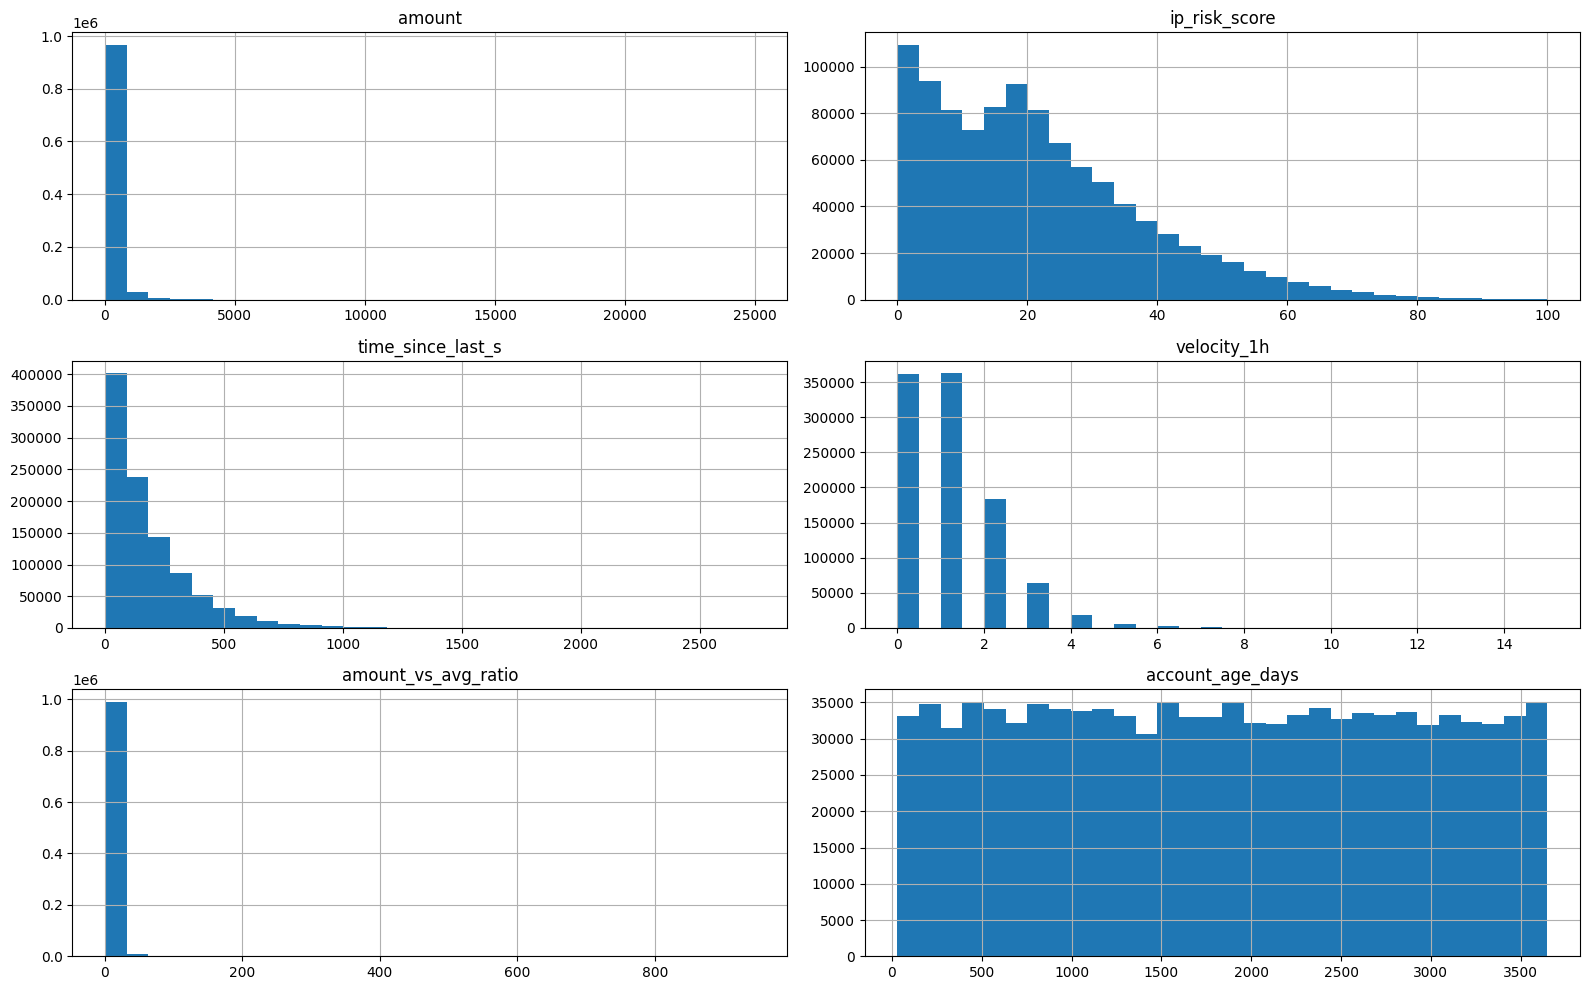

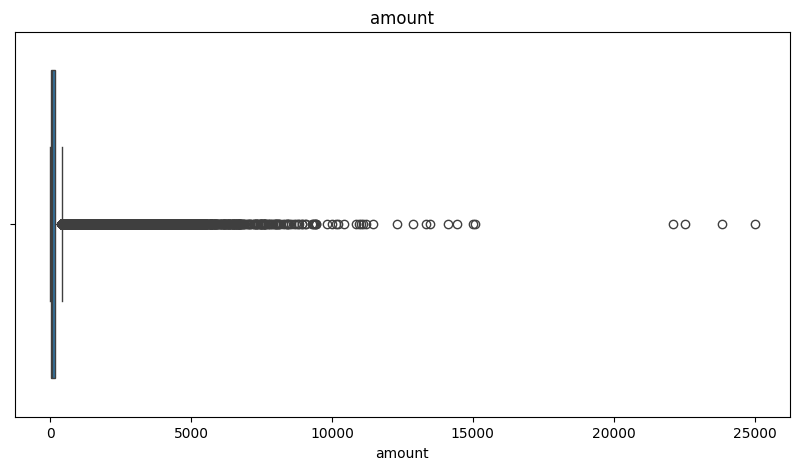

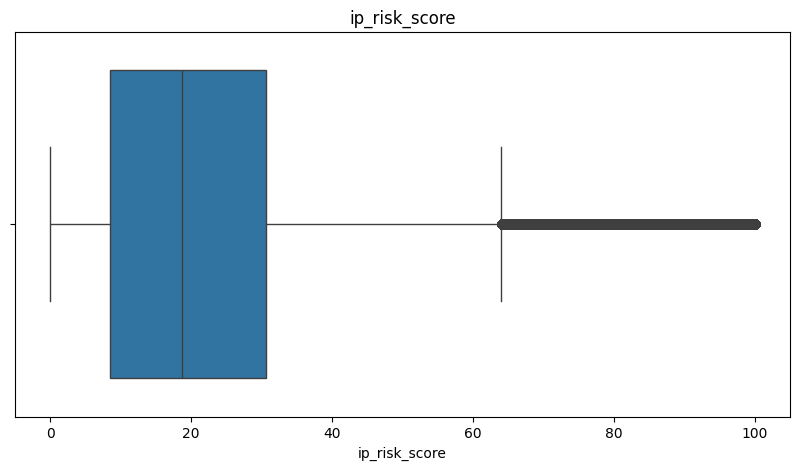

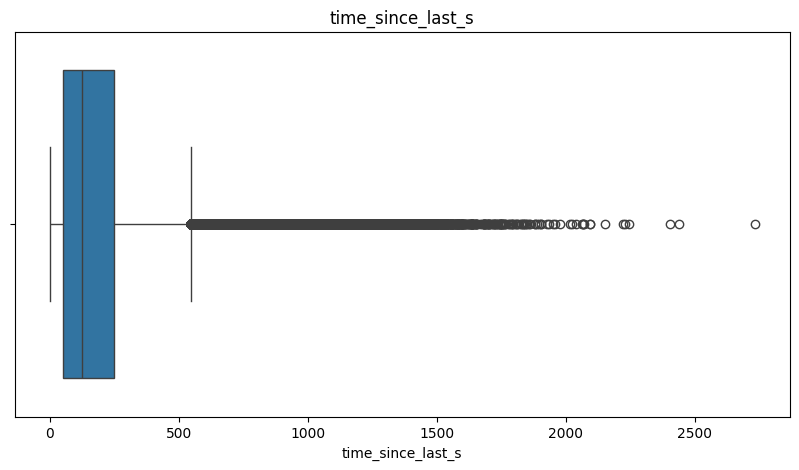

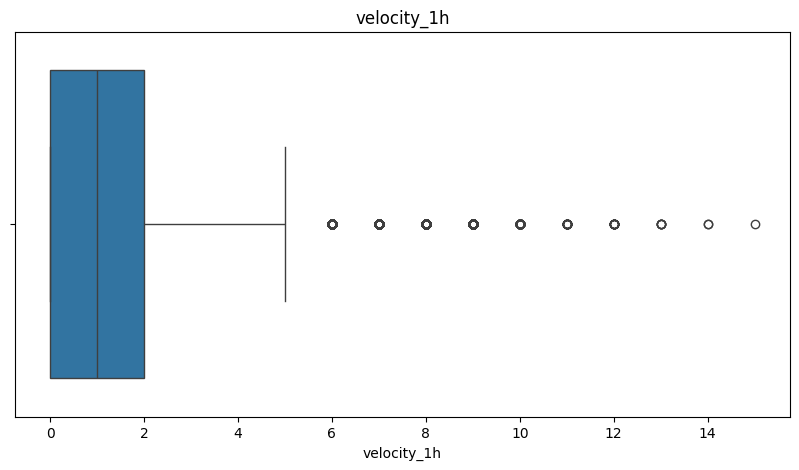

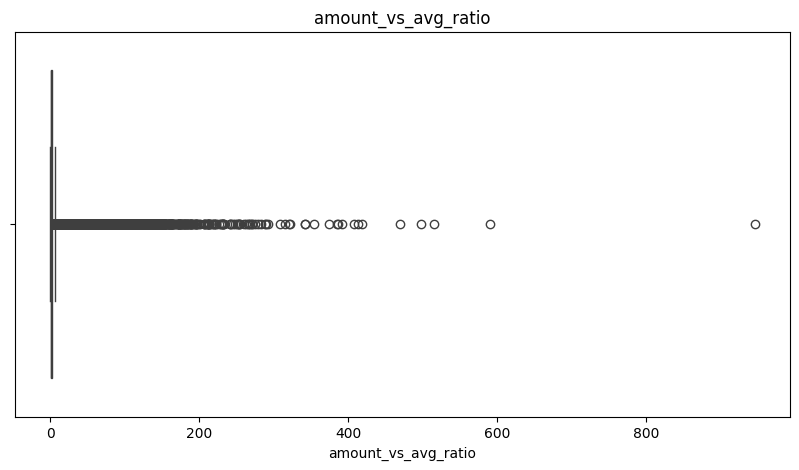

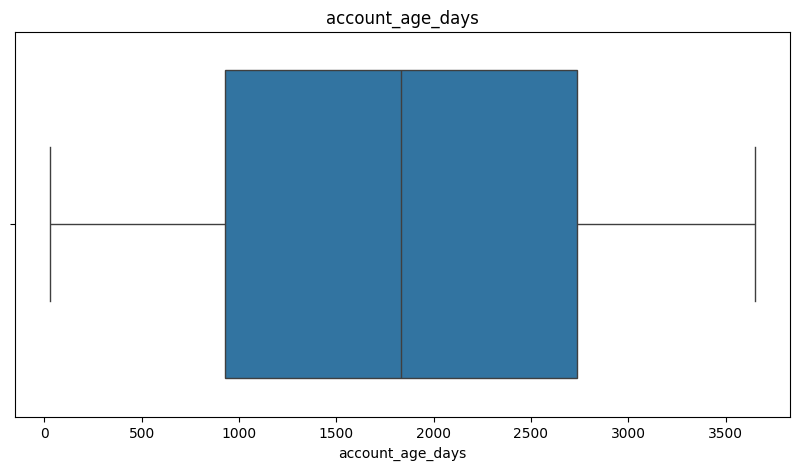

In [8]:
num_cols = [
    'amount',
    'ip_risk_score',
    'time_since_last_s',
    'velocity_1h',
    'amount_vs_avg_ratio',
    'account_age_days'
]
df[num_cols].describe().T
df[num_cols].hist(figsize=(16, 10), bins=30)
plt.tight_layout()
plt.show()
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## **6. Categorical EDA**

\n===== merchant_category =====
merchant_category
grocery          180167
online_retail    150118
restaurant       120406
gas_station       80030
atm               79595
clothing          70072
pharmacy          60295
electronics       60229
hotel             49490
travel            49367
Name: count, dtype: int64
\n===== merchant_country =====
merchant_country
US    705583
CA     39392
GB     39261
FR     39239
DE     39190
AU     38890
RO     19876
NG     19749
CN     19657
MX     19613
Name: count, dtype: int64
\n===== device_type =====
device_type
mobile_app      399875
pos_terminal    250109
web_browser     249471
atm              70170
phone_ivr        30375
Name: count, dtype: int64


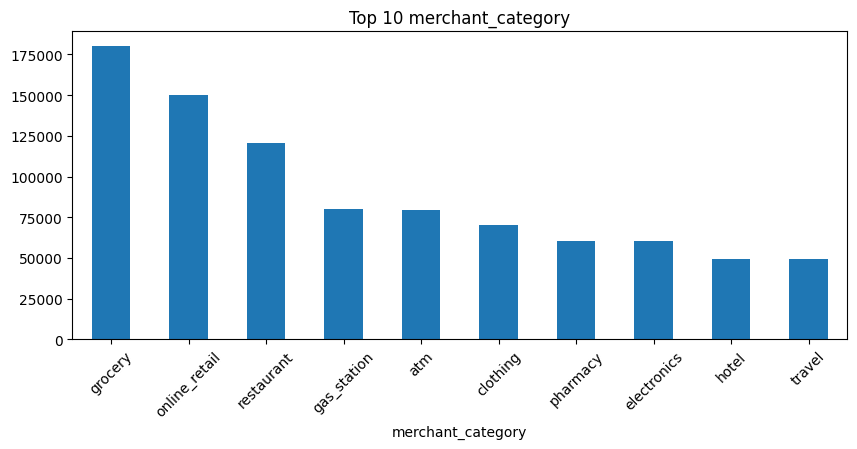

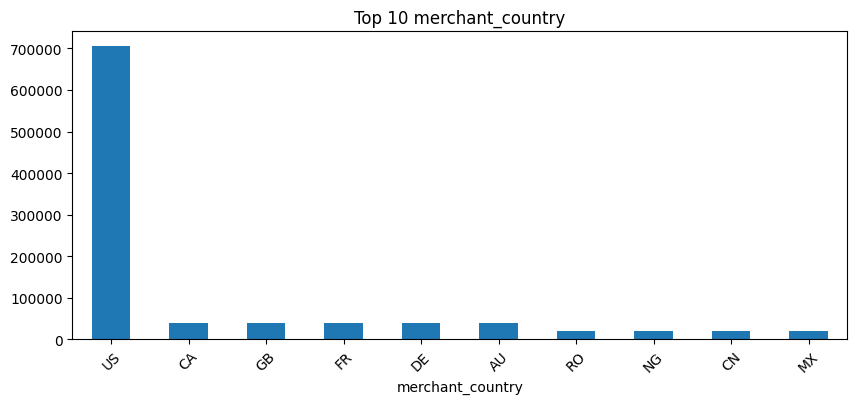

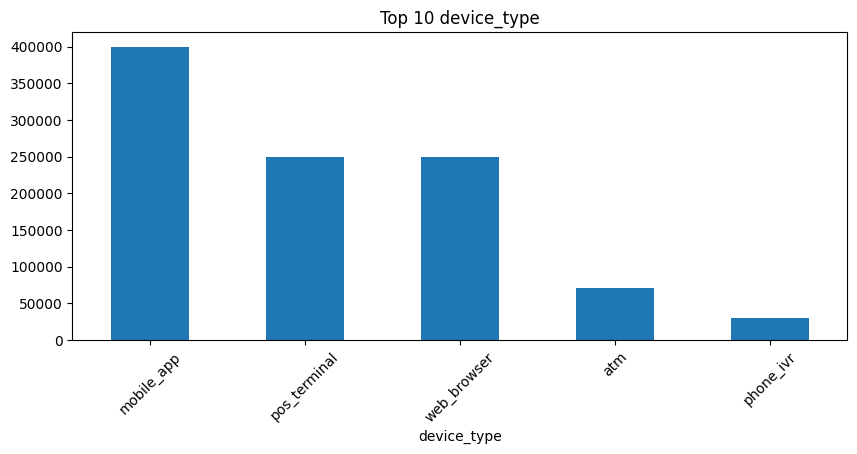

In [9]:
cat_cols = ['merchant_category', 'merchant_country', 'device_type']

for col in cat_cols:
    print(f'\\n===== {col} =====')
    print(df[col].value_counts().head(10))
for col in cat_cols:
    plt.figure(figsize=(10,4))
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'Top 10 {col}')
    plt.xticks(rotation=45)
    plt.show()

## **7. Bivariate EDA với Fraud**

In [10]:
eda_sample = df.sample(100000, random_state=42)

### **7.1. Amount vs fraud**

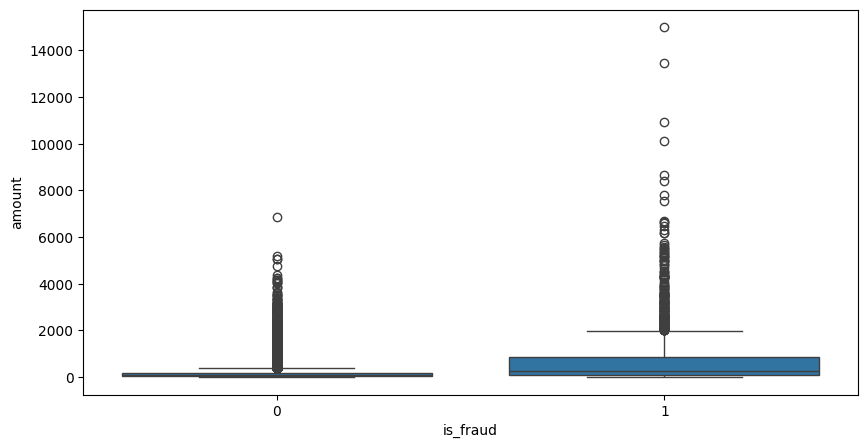

In [11]:
sns.boxplot(data=eda_sample, x='is_fraud', y='amount')
plt.show()

### **7.2 Risk score vs fraud**

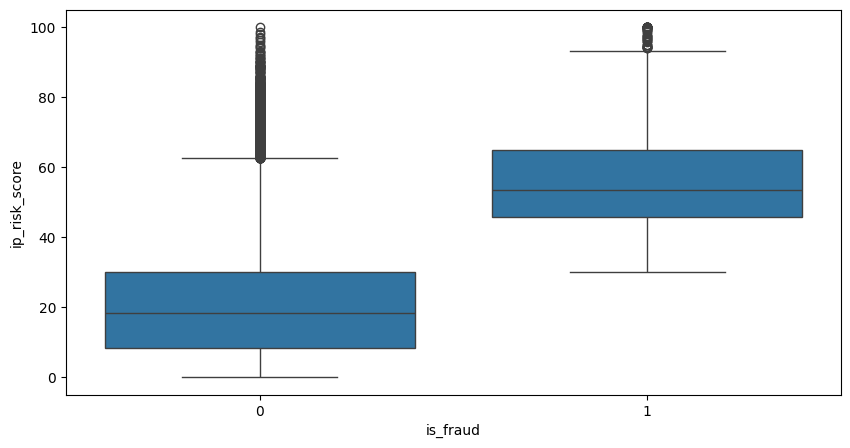

In [12]:
sns.boxplot(data=eda_sample, x='is_fraud', y='ip_risk_score')
plt.show()

### **7.3 Velocity vs fraud**

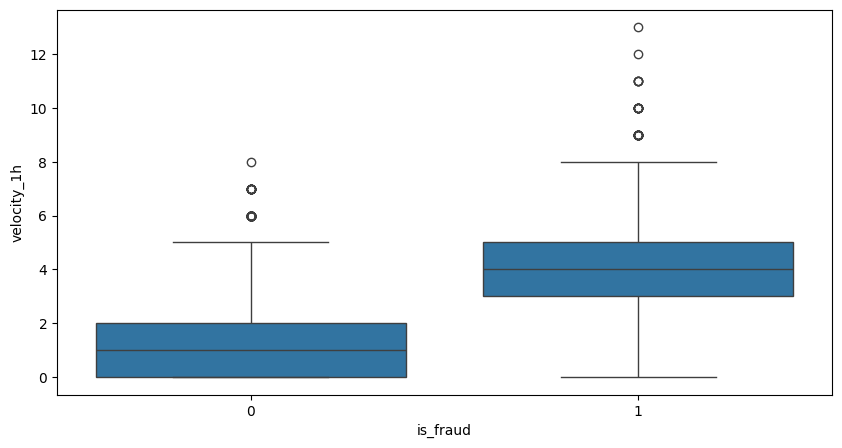

In [13]:
sns.boxplot(data=eda_sample, x='is_fraud', y='velocity_1h')
plt.show()

## **8. Fraud Rate according to Category**

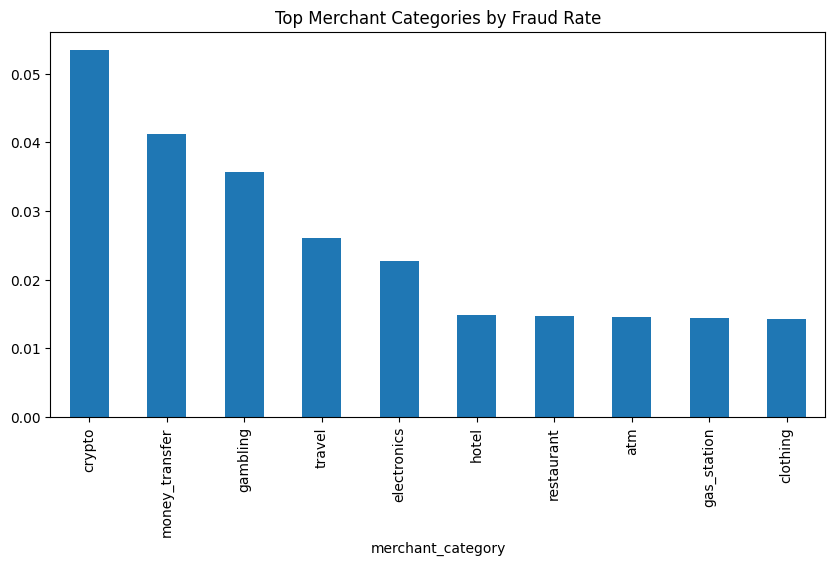

In [14]:
merchant_fraud = (
    df.groupby('merchant_category')['is_fraud']
      .mean()
      .sort_values(ascending=False)
)
merchant_fraud.head(10)
merchant_fraud.head(10).plot(kind='bar')
plt.title('Top Merchant Categories by Fraud Rate')
plt.show()

## **9. Time-based EDA**

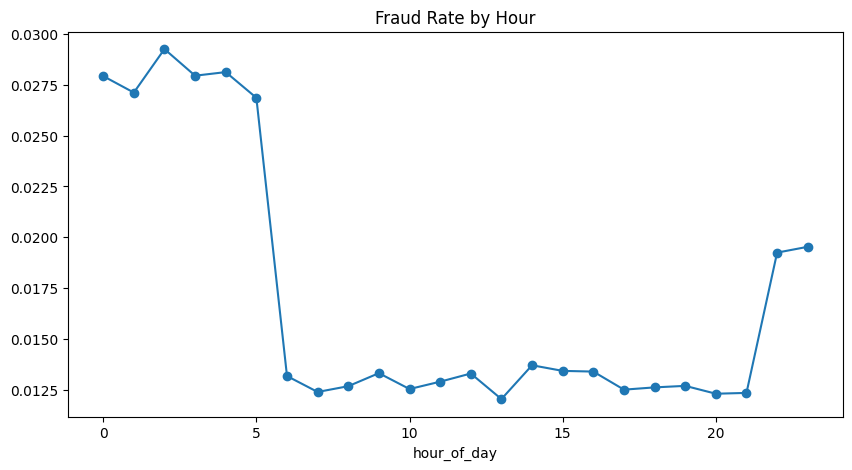

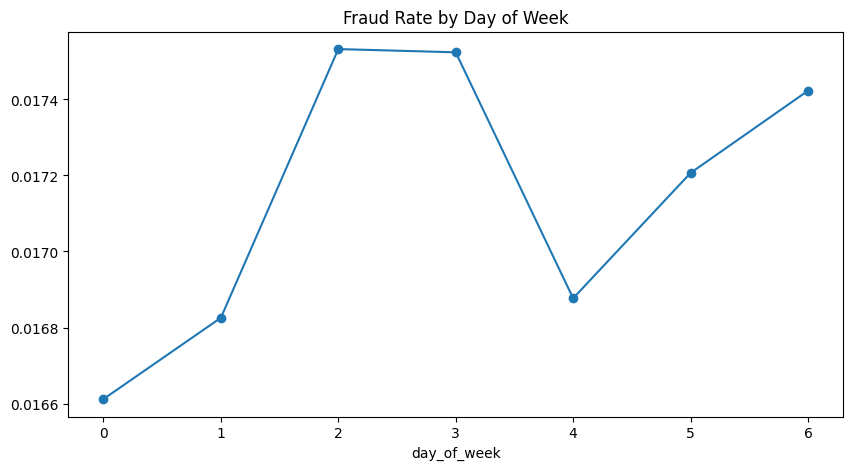

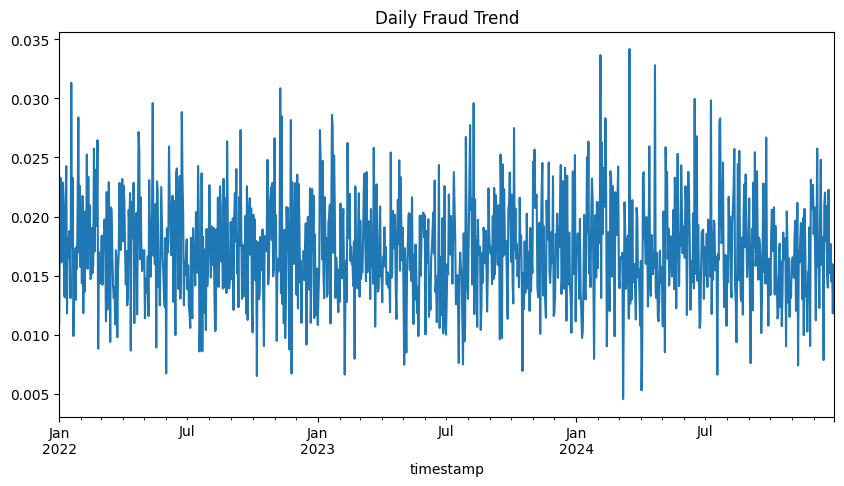

In [16]:
df.groupby('hour_of_day')['is_fraud'].mean().plot(marker='o')
plt.title('Fraud Rate by Hour')
plt.show()
df.groupby('day_of_week')['is_fraud'].mean().plot(marker='o')
plt.title('Fraud Rate by Day of Week')
plt.show()
daily_fraud = df.set_index('timestamp').resample('D')['is_fraud'].mean()
daily_fraud.plot()
plt.title('Daily Fraud Trend')
plt.show()

## **10. Correlation + Leakage Check**

In [17]:
corr = df.corr(numeric_only=True)['is_fraud'].sort_values(ascending=False)
print(corr)

is_fraud               1.000000
velocity_1h            0.351743
ip_risk_score          0.273928
amount                 0.227860
amount_vs_avg_ratio    0.183140
is_foreign_txn         0.083682
day_of_week            0.001401
is_weekend             0.000840
time_since_last_s      0.000470
credit_limit          -0.001196
account_age_days      -0.002574
mcc_code              -0.007904
has_2fa               -0.018033
card_present          -0.024431
hour_of_day           -0.031430
device_known          -0.187589
Name: is_fraud, dtype: float64


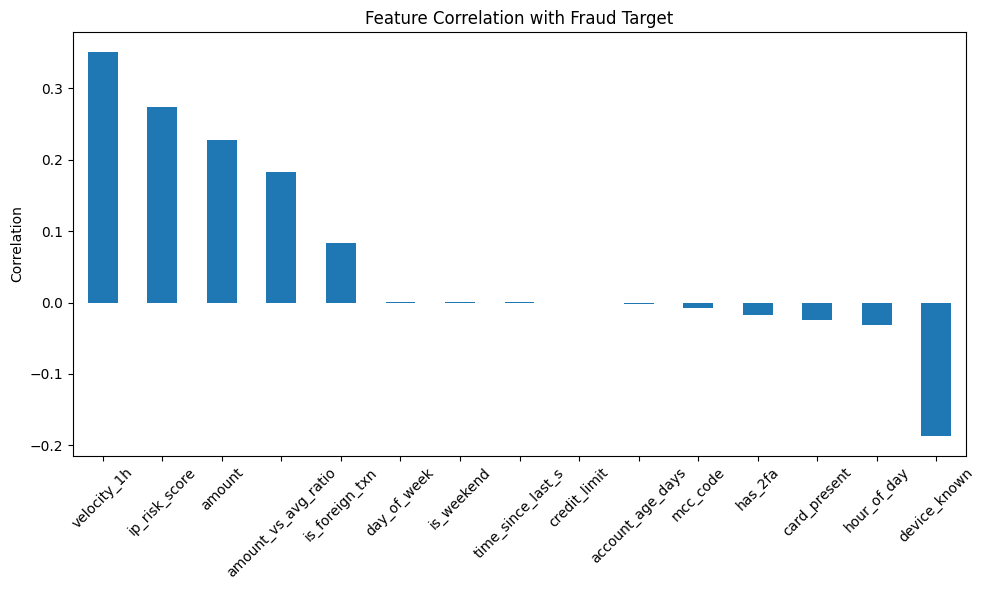

In [21]:
corr_target = (
    df.corr(numeric_only=True)['is_fraud']
      .drop('is_fraud')
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
corr_target.plot(kind='bar')
plt.title('Feature Correlation with Fraud Target')
plt.ylabel('Correlation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

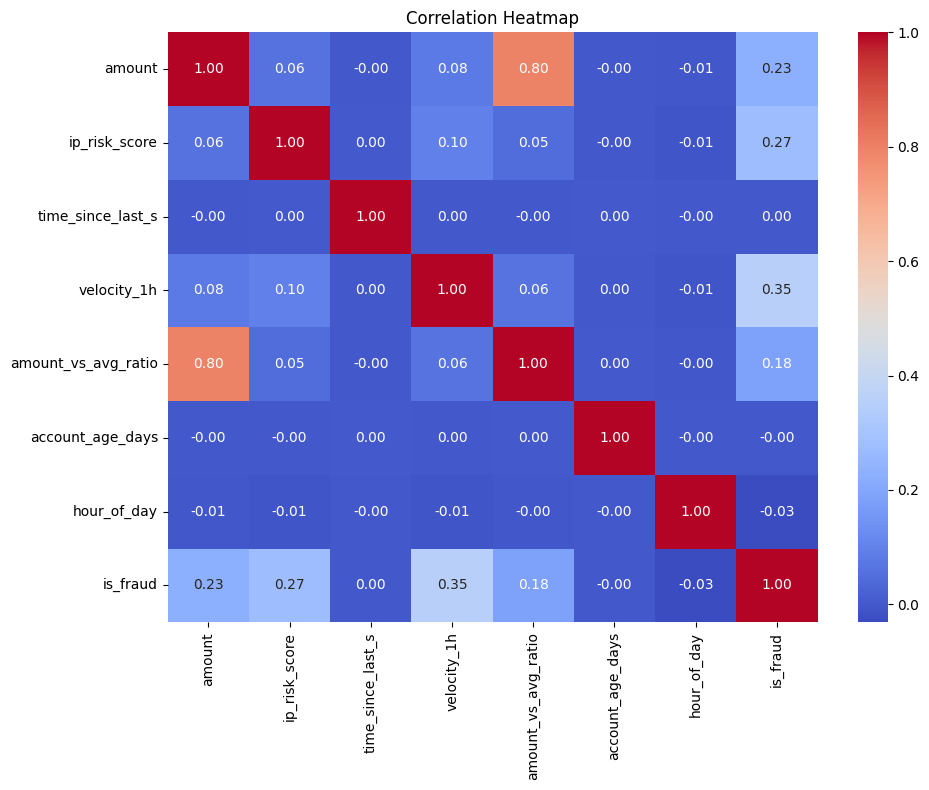

In [22]:
num_corr_cols = [
    'amount', 'ip_risk_score', 'time_since_last_s',
    'velocity_1h', 'amount_vs_avg_ratio',
    'account_age_days', 'hour_of_day', 'is_fraud'
]

corr_matrix = df[num_corr_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## **11. Business Rule Validation**

In [18]:
print(df.groupby('is_foreign_txn')['is_fraud'].mean())
print(df.groupby('device_known')['is_fraud'].mean())
print(df.groupby('has_2fa')['is_fraud'].mean())

is_foreign_txn
0    0.010126
1    0.033959
Name: is_fraud, dtype: float64
device_known
0    0.087244
1    0.008685
Name: is_fraud, dtype: float64
has_2fa
0    0.020316
1    0.015416
Name: is_fraud, dtype: float64
